# Query LLM Stats Analysis

This notebook analyzes `query_llm_stats.csv` produced by the query logging pipeline.
It focuses on latency, RAG confidence, usage patterns, and response/context size statistics.


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional styling if seaborn is available
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='talk')
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False
    plt.style.use('ggplot')

plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)


In [26]:
csv_path = Path('query_llm_stats.csv')
if not csv_path.exists():
    # Fallback if notebook is opened from repo root instead of notebook directory
    csv_path = Path('actint/src/actint/actint_logging/query_llm_stats.csv')

print(f'Loading CSV from: {csv_path.resolve()}')
df = pd.read_csv(csv_path)

# Parse and normalize types
if 'timestamp_utc' in df.columns:
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')

for col in ['matches_found', 'rag_distance_score', 'rag_confidence', 'total_time_seconds', 'llm_inference_time_seconds']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'use_llm' in df.columns:
    df['use_llm'] = df['use_llm'].astype(str).str.lower().map({'true': True, 'false': False})

# Text-derived features
for col in ['query', 'context', 'response']:
    if col in df.columns:
        df[f'{col}_chars'] = df[col].fillna('').astype(str).str.len()
        df[f'{col}_words'] = df[col].fillna('').astype(str).str.split().str.len()

# Sort for time-series plots
if 'timestamp_utc' in df.columns:
    df = df.sort_values('timestamp_utc').reset_index(drop=True)

print(f'Rows: {len(df)}')
print('Columns:', list(df.columns))
df.head()


Loading CSV from: /home/isaacp/repos/directlabs/JFN-Groundtruth-Simulator/actint/src/actint/actint_logging/query_llm_stats.csv
Rows: 8
Columns: ['timestamp_utc', 'query', 'context', 'response', 'use_llm', 'matches_found', 'rag_distance_score', 'rag_confidence', 'total_time_seconds', 'llm_inference_time_seconds', 'query_chars', 'query_words', 'context_chars', 'context_words', 'response_chars', 'response_words']


,timestamp_utc,query,context,response,use_llm,matches_found,rag_distance_score,rag_confidence,total_time_seconds,llm_inference_time_seconds,query_chars,query_words,context_chars,context_words,response_chars,response_words
0,2026-02-26 18:54:09.702485+00:00,Where is USS KIDD right now?,=== USS KIDD ===\nVessel Info: Designation: DDG-100. Class: ARLEIGH BRUKE. Fleet: US_PAC_FLEET. Home Port: Naval Sta...,"USS KIDD is currently near Los Angeles, CA, in the Pacific Ocean (Central).",True,3,0.657338,0.603377,1.227072,0.957349,28,6,396,50,75,13
1,2026-02-26 18:54:10.548462+00:00,What is the position of USS MONTGOMERY?,"=== USS MONTGOMERY ===\nVessel Info: Designation: LCS-8. Class: FREEDOM. Fleet: US_3RD_FLEET. Home Port: San Diego, ...","The position of USS MONTGOMERY is at 32.85930°N, 117.86774°W.",True,3,0.597092,0.626138,0.845669,0.719388,39,7,376,48,61,9
2,2026-02-26 19:05:41.384458+00:00,Where is USS KIDD right now?,=== USS KIDD ===\nVessel Info: Designation: DDG-100. Class: ARLEIGH BRUKE. Fleet: US_PAC_FLEET. Home Port: Naval Sta...,"USS KIDD is currently near Los Angeles, CA.",True,3,0.657338,0.603377,0.718416,0.576618,28,6,396,50,43,8
3,2026-02-26 19:05:42.205626+00:00,What is the position of USS MONTGOMERY?,"=== USS MONTGOMERY ===\nVessel Info: Designation: LCS-8. Class: FREEDOM. Fleet: US_3RD_FLEET. Home Port: San Diego, ...","The position of USS MONTGOMERY is 32.85930°N, 117.86774°W.",True,3,0.597092,0.626138,0.820919,0.690148,39,7,376,48,58,8
4,2026-02-26 19:12:36.258166+00:00,What is the USS BANANA doing right now?,=== USS THEODORE ROOSEVE ===\nVessel Info: Designation: CVN-71. Class: NIMITZ. Fleet: US_PAC_FLEET. Home Port: San D...,"Based on the provided information, the USS BANANA is not a real vessel, and therefore, it is not currently doing any...",True,3,1.131935,0.469057,0.999501,0.852553,39,8,387,50,122,21


In [27]:
# High-level summary metrics
summary = {
    'num_queries': len(df),
    'time_range_start_utc': df['timestamp_utc'].min() if 'timestamp_utc' in df.columns and not df.empty else None,
    'time_range_end_utc': df['timestamp_utc'].max() if 'timestamp_utc' in df.columns and not df.empty else None,
    'llm_usage_rate': float(df['use_llm'].mean()) if 'use_llm' in df.columns and len(df) else np.nan,
    'avg_total_latency_s': df['total_time_seconds'].mean() if 'total_time_seconds' in df.columns else np.nan,
    'p95_total_latency_s': df['total_time_seconds'].quantile(0.95) if 'total_time_seconds' in df.columns and len(df) else np.nan,
    'avg_inference_latency_s': df['llm_inference_time_seconds'].mean() if 'llm_inference_time_seconds' in df.columns else np.nan,
    'avg_rag_confidence': df['rag_confidence'].mean() if 'rag_confidence' in df.columns else np.nan,
    'avg_matches_found': df['matches_found'].mean() if 'matches_found' in df.columns else np.nan,
}

pd.Series(summary, name='value')


num_queries                                               8
time_range_start_utc       2026-02-26 18:54:09.702485+00:00
time_range_end_utc         2026-02-26 19:30:18.783452+00:00
llm_usage_rate                                          1.0
avg_total_latency_s                                1.142813
p95_total_latency_s                                1.866689
avg_inference_latency_s                            0.986202
avg_rag_confidence                                 0.559986
avg_matches_found                                       3.0
Name: value, dtype: object

In [28]:
# Detailed descriptive stats for core numeric columns
numeric_cols = [
    c for c in [
        'matches_found', 'rag_distance_score', 'rag_confidence',
        'total_time_seconds', 'llm_inference_time_seconds',
        'query_chars', 'context_chars', 'response_chars',
        'query_words', 'context_words', 'response_words'
    ] if c in df.columns
]

if numeric_cols:
    display(df[numeric_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)
else:
    print('No numeric columns available for descriptive stats.')


,count,mean,std,min,50%,90%,95%,99%,max
matches_found,8.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
rag_distance_score,8.0,0.812815,0.243972,0.597092,0.670193,1.131935,1.131935,1.131935,1.131935
rag_confidence,8.0,0.559986,0.071034,0.469057,0.598769,0.626138,0.626138,0.626138,0.626138
total_time_seconds,8.0,1.142813,0.461003,0.718416,0.922585,1.816298,1.866689,1.907002,1.917080
llm_inference_time_seconds,8.0,0.986202,0.458167,0.576618,0.785971,1.672317,1.724404,1.766072,1.776490
query_chars,8.0,38.375000,7.327785,28.000000,39.000000,46.200000,47.600000,48.720000,49.000000
context_chars,8.0,386.125000,7.698562,376.000000,387.000000,396.000000,396.000000,396.000000,396.000000
response_chars,8.0,104.250000,67.124086,43.000000,69.000000,202.000000,209.000000,214.600000,216.000000
query_words,8.0,7.375000,1.302470,6.000000,7.000000,8.600000,9.300000,9.860000,10.000000
context_words,8.0,49.625000,1.302470,48.000000,50.000000,50.600000,51.300000,51.860000,52.000000


## Latency Plots
These plots show total latency and LLM inference latency distributions, plus trend over time.


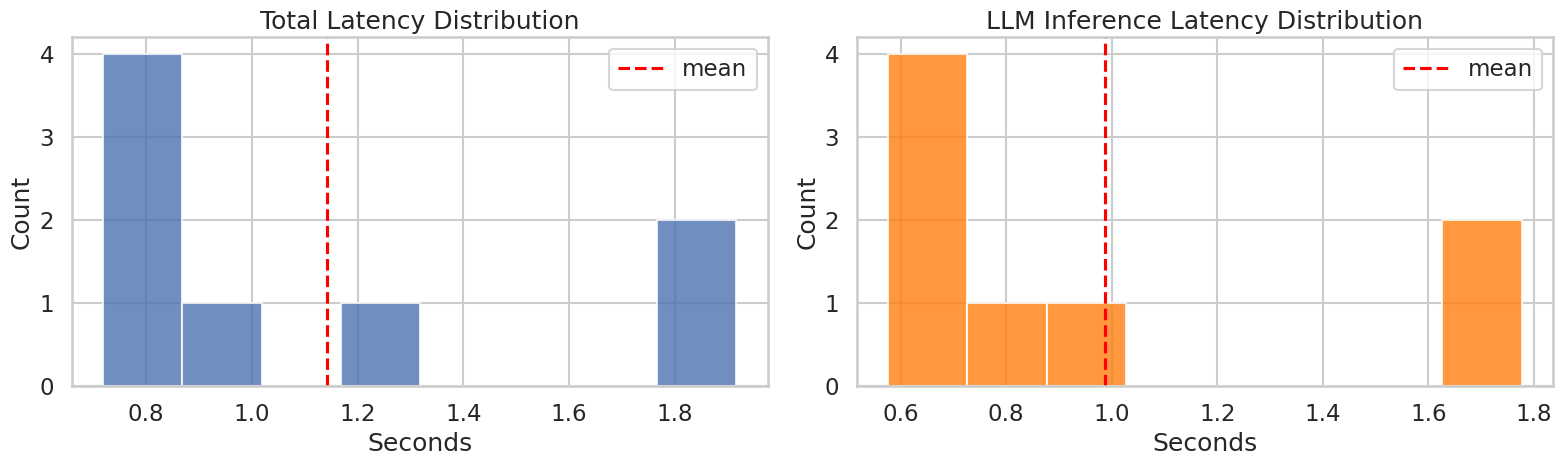

In [29]:
if df.empty:
    print('No rows to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    if 'total_time_seconds' in df.columns:
        axes[0].hist(df['total_time_seconds'].dropna(), bins=min(20, max(5, len(df))), alpha=0.8)
        axes[0].axvline(df['total_time_seconds'].mean(), color='red', linestyle='--', label='mean')
        axes[0].set_title('Total Latency Distribution')
        axes[0].set_xlabel('Seconds')
        axes[0].set_ylabel('Count')
        axes[0].legend()
    else:
        axes[0].set_visible(False)

    if 'llm_inference_time_seconds' in df.columns:
        axes[1].hist(df['llm_inference_time_seconds'].dropna(), bins=min(20, max(5, len(df))), alpha=0.8, color='tab:orange')
        axes[1].axvline(df['llm_inference_time_seconds'].mean(), color='red', linestyle='--', label='mean')
        axes[1].set_title('LLM Inference Latency Distribution')
        axes[1].set_xlabel('Seconds')
        axes[1].set_ylabel('Count')
        axes[1].legend()
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()


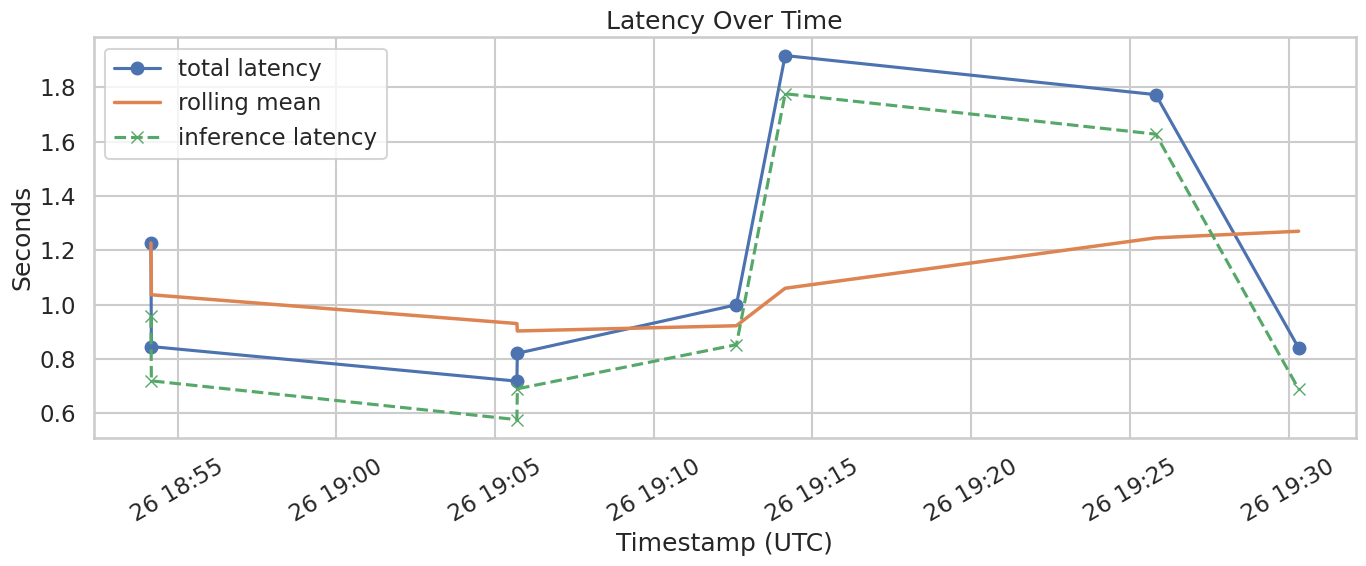

In [30]:
if len(df) > 0 and 'timestamp_utc' in df.columns and 'total_time_seconds' in df.columns:
    plot_df = df.dropna(subset=['timestamp_utc', 'total_time_seconds']).copy()
    if not plot_df.empty:
        plot_df['rolling_total_latency_s'] = plot_df['total_time_seconds'].rolling(window=min(5, len(plot_df)), min_periods=1).mean()

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(plot_df['timestamp_utc'], plot_df['total_time_seconds'], marker='o', label='total latency')
        ax.plot(plot_df['timestamp_utc'], plot_df['rolling_total_latency_s'], linewidth=2.5, label='rolling mean')
        if 'llm_inference_time_seconds' in plot_df.columns:
            ax.plot(plot_df['timestamp_utc'], plot_df['llm_inference_time_seconds'], marker='x', linestyle='--', label='inference latency')
        ax.set_title('Latency Over Time')
        ax.set_xlabel('Timestamp (UTC)')
        ax.set_ylabel('Seconds')
        ax.legend()
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        print('No valid timestamps/latencies to plot.')
else:
    print('Required columns missing for time series latency plot.')


## RAG Quality / Confidence
Relationship between top-match RAG confidence and latency/response size.


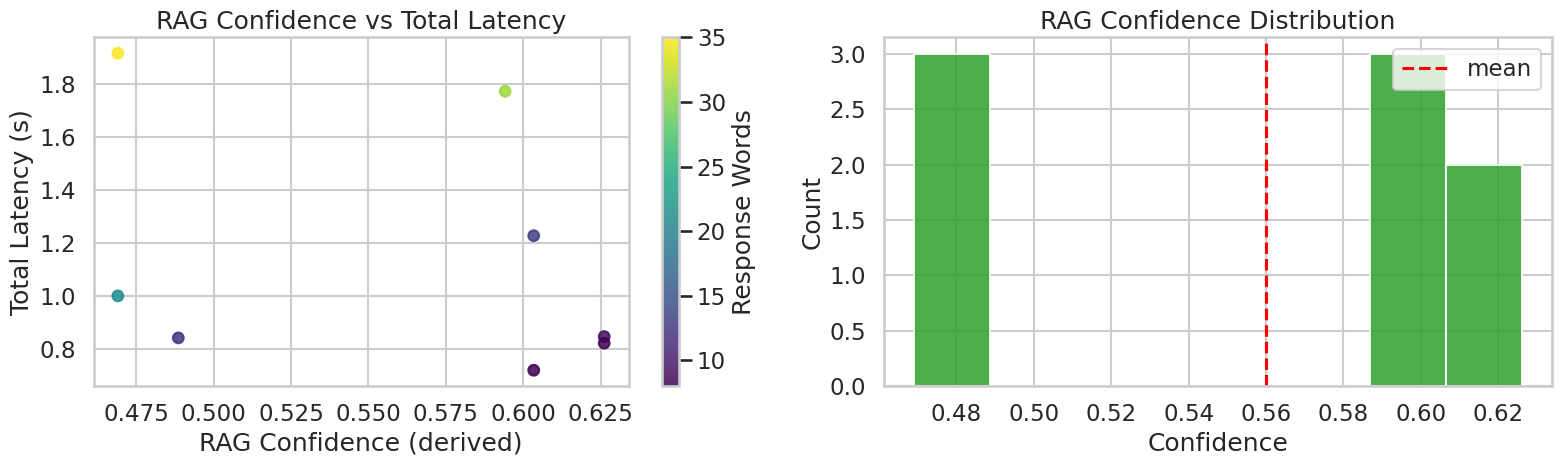

In [31]:
if {'rag_confidence', 'total_time_seconds'}.issubset(df.columns):
    plot_df = df.dropna(subset=['rag_confidence', 'total_time_seconds']).copy()
    if not plot_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        scatter_size = 60
        cvals = plot_df['response_words'] if 'response_words' in plot_df.columns else None
        sc = axes[0].scatter(
            plot_df['rag_confidence'],
            plot_df['total_time_seconds'],
            s=scatter_size,
            c=cvals,
            cmap='viridis' if cvals is not None else None,
            alpha=0.85,
        )
        axes[0].set_title('RAG Confidence vs Total Latency')
        axes[0].set_xlabel('RAG Confidence (derived)')
        axes[0].set_ylabel('Total Latency (s)')
        if cvals is not None:
            cbar = plt.colorbar(sc, ax=axes[0])
            cbar.set_label('Response Words')

        axes[1].hist(plot_df['rag_confidence'], bins=min(20, max(5, len(plot_df))), color='tab:green', alpha=0.85)
        axes[1].axvline(plot_df['rag_confidence'].mean(), color='red', linestyle='--', label='mean')
        axes[1].set_title('RAG Confidence Distribution')
        axes[1].set_xlabel('Confidence')
        axes[1].set_ylabel('Count')
        axes[1].legend()

        plt.tight_layout()
        plt.show()
    else:
        print('No valid confidence values found.')
else:
    print('Required columns missing for RAG confidence plots.')


## Text Size and Throughput
Context and response sizes often drive latency. These plots help spot scaling behavior.


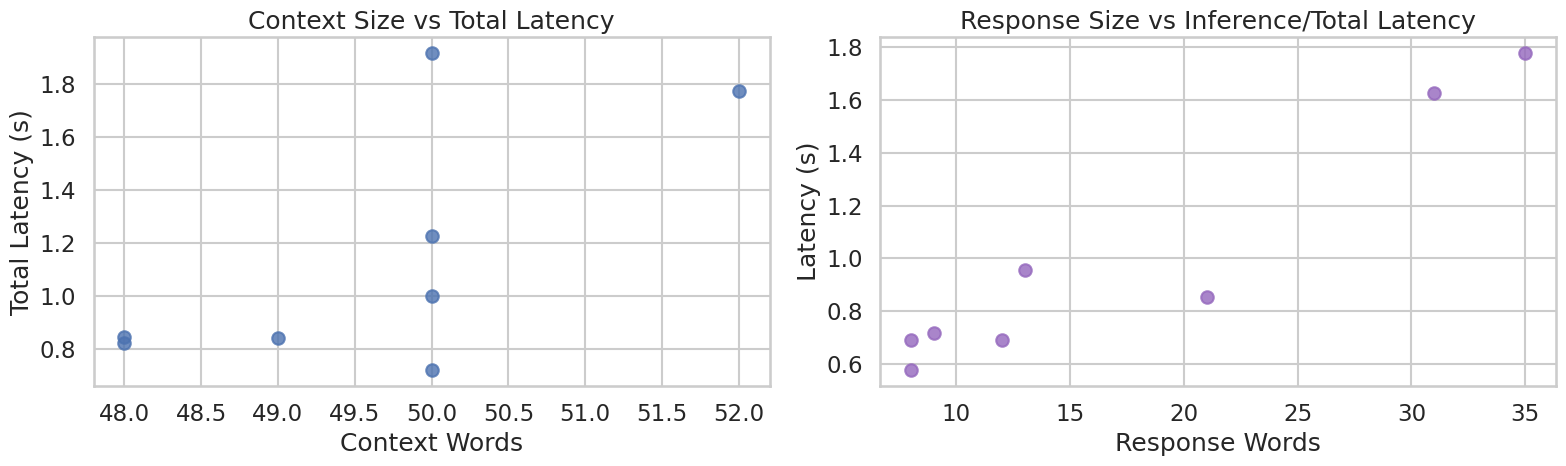

In [32]:
available = set(df.columns)
needed_scatter = {'context_words', 'response_words', 'total_time_seconds'}

if needed_scatter.issubset(available):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].scatter(df['context_words'], df['total_time_seconds'], alpha=0.8)
    axes[0].set_title('Context Size vs Total Latency')
    axes[0].set_xlabel('Context Words')
    axes[0].set_ylabel('Total Latency (s)')

    axes[1].scatter(df['response_words'], df['llm_inference_time_seconds'] if 'llm_inference_time_seconds' in df.columns else df['total_time_seconds'], alpha=0.8, color='tab:purple')
    axes[1].set_title('Response Size vs Inference/Total Latency')
    axes[1].set_xlabel('Response Words')
    axes[1].set_ylabel('Latency (s)')

    plt.tight_layout()
    plt.show()
else:
    print('Missing columns for size/throughput scatter plots.')


In [33]:
# Top queries by frequency and by latency (useful once logs grow)
if 'query' not in df.columns or df.empty:
    print('No query data available.')
else:
    print('Top queries by count')
    display(df['query'].value_counts().rename_axis('query').reset_index(name='count').head(10))

    if 'total_time_seconds' in df.columns:
        by_query = (
            df.groupby('query', dropna=False)
              .agg(count=('query', 'size'), avg_total_latency_s=('total_time_seconds', 'mean'), max_total_latency_s=('total_time_seconds', 'max'))
              .sort_values(['avg_total_latency_s', 'count'], ascending=[False, False])
        )
        print('Top queries by average total latency')
        display(by_query.head(10))


Top queries by count


,query,count
0,Where is USS KIDD right now?,2
1,What is the position of USS MONTGOMERY?,2
2,What is the USS BANANA doing right now?,1
3,What is the USS BANANA doing right now?,1
4,Where has the USS KEARSAGE been the last two days,1
5,Which ship is currently traveling the fastest,1


Top queries by average total latency


,count,avg_total_latency_s,max_total_latency_s
query,,,
What is the USS BANANA doing right now?,1,1.917080,1.917080
Where has the USS KEARSAGE been the last two days,1,1.773106,1.773106
What is the USS BANANA doing right now?,1,0.999501,0.999501
Where is USS KIDD right now?,2,0.972744,1.227072
Which ship is currently traveling the fastest,1,0.840742,0.840742
What is the position of USS MONTGOMERY?,2,0.833294,0.845669


## Correlation Heatmap
Use this to identify which variables appear to move together (latency, confidence, text size, etc.).


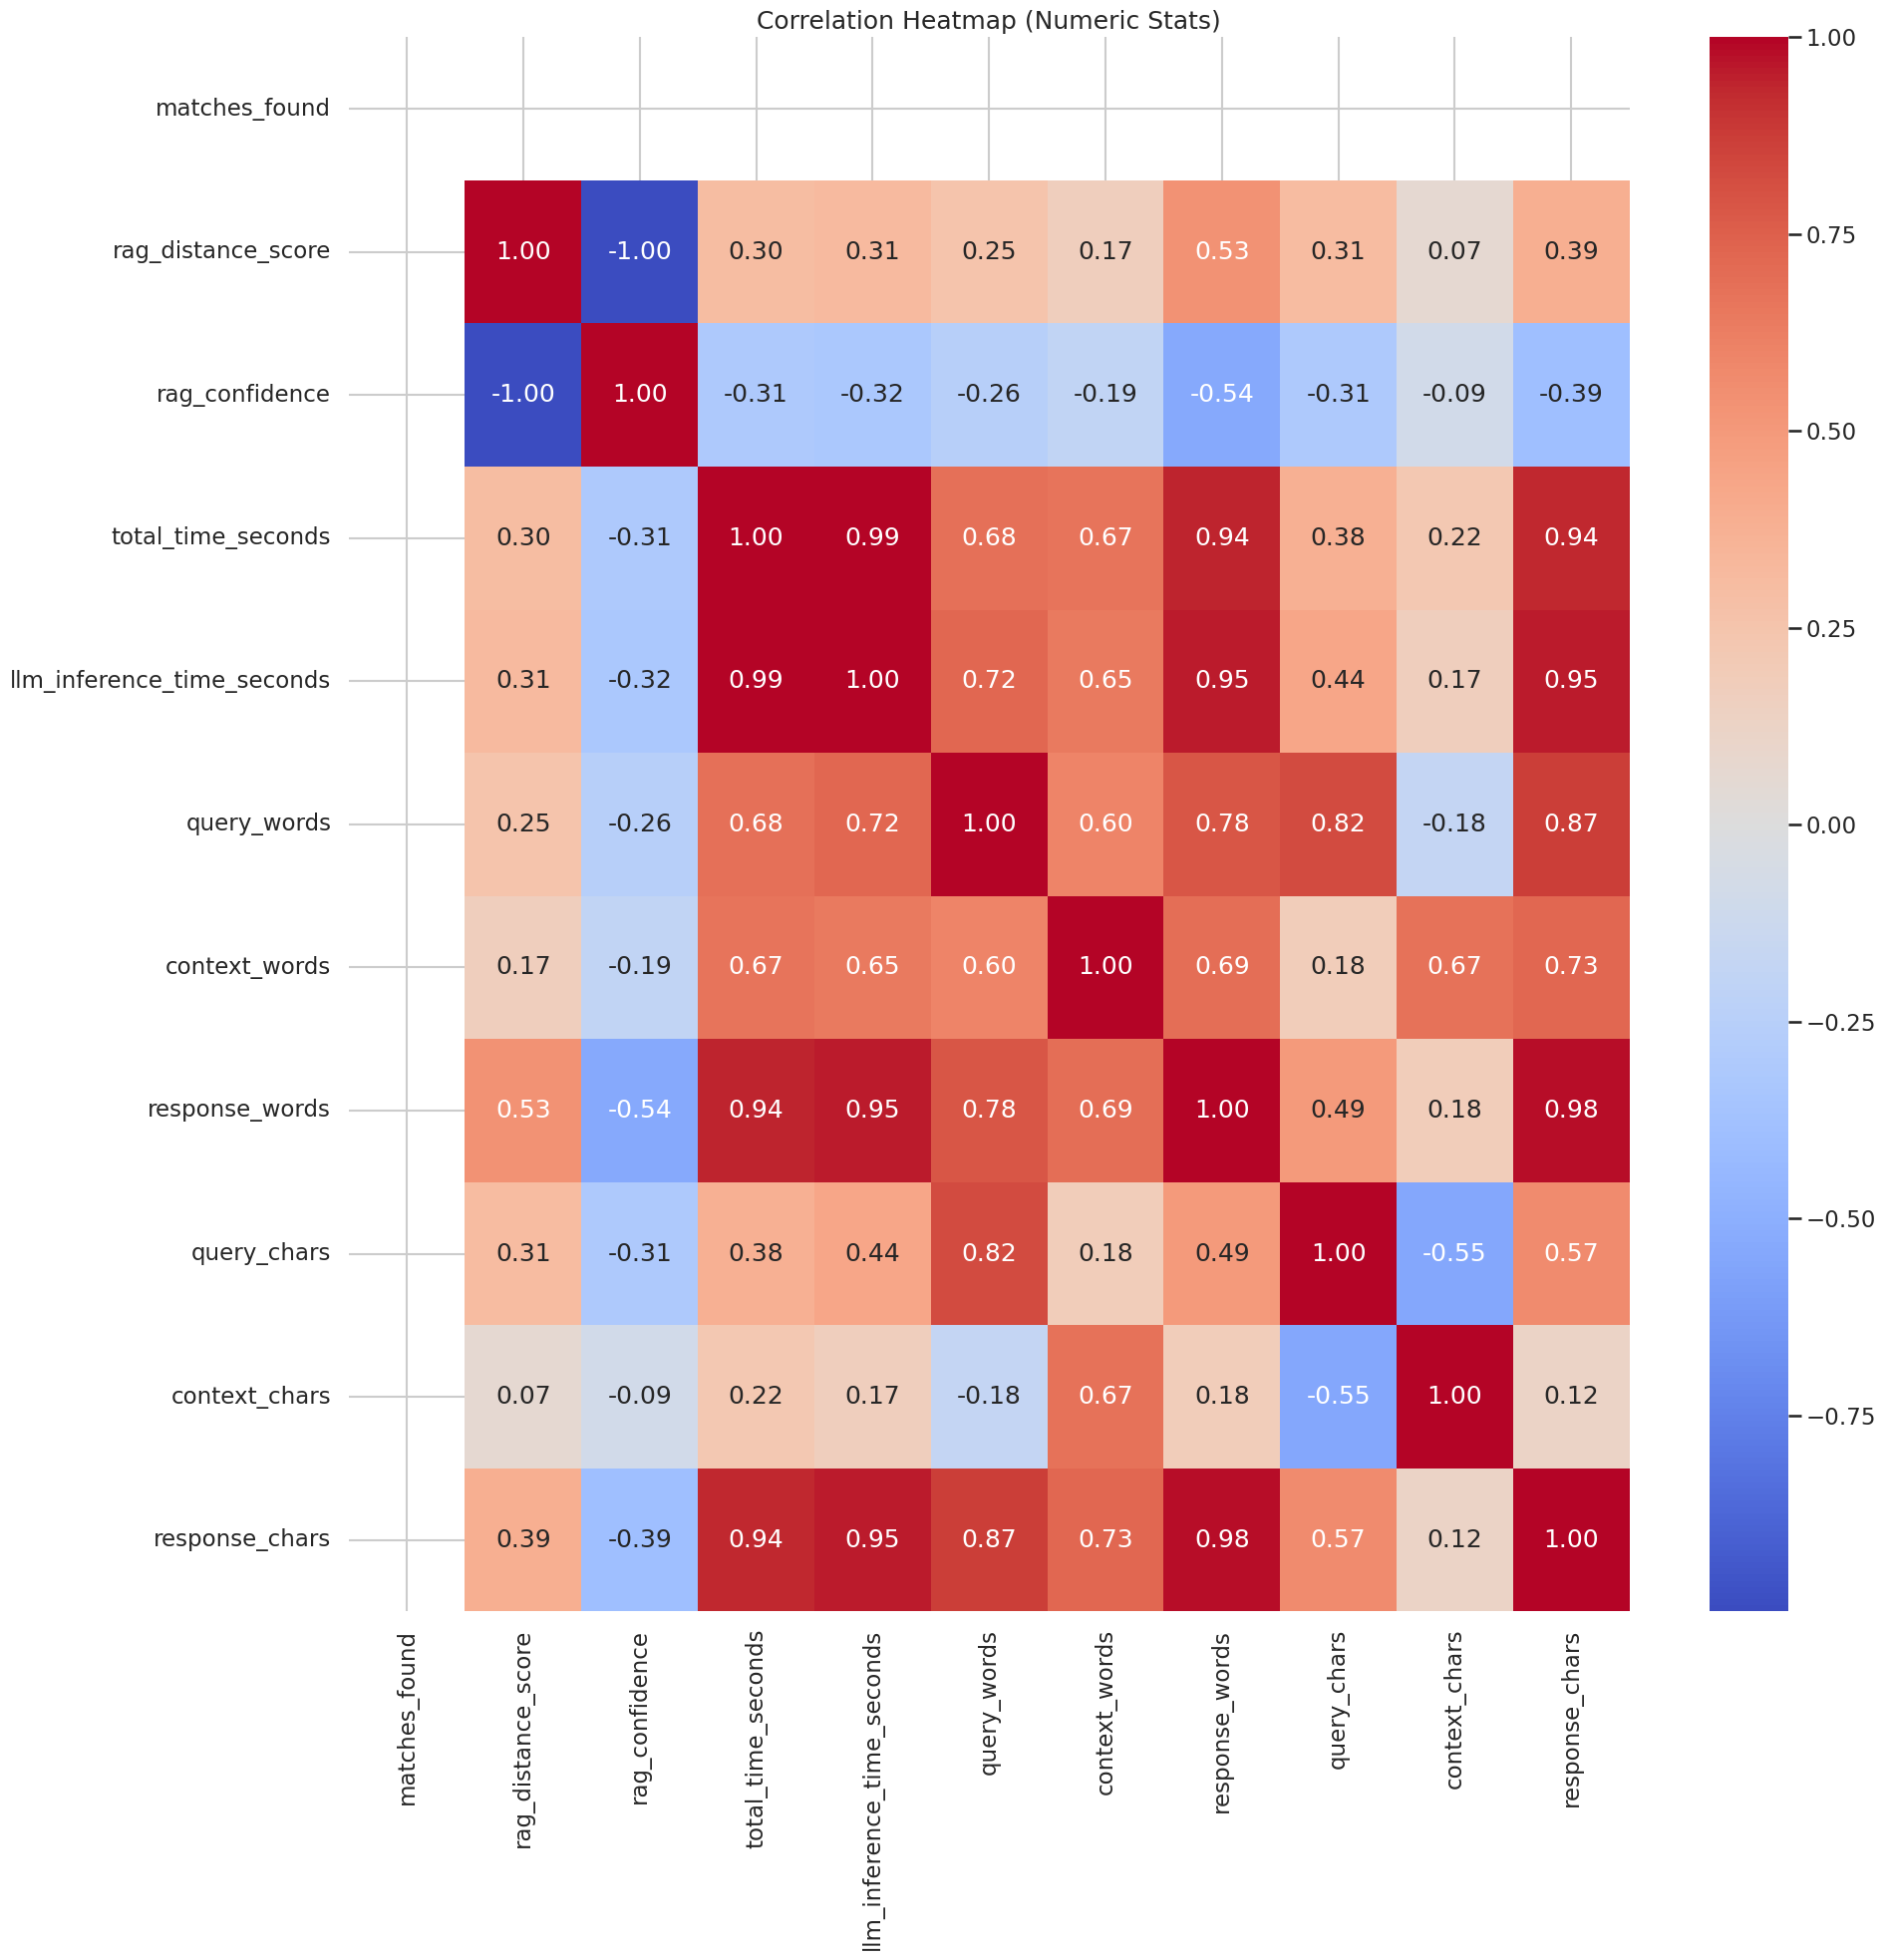

In [34]:
corr_cols = [
    c for c in [
        'matches_found', 'rag_distance_score', 'rag_confidence',
        'total_time_seconds', 'llm_inference_time_seconds',
        'query_words', 'context_words', 'response_words',
        'query_chars', 'context_chars', 'response_chars'
    ] if c in df.columns
]

if len(corr_cols) >= 2 and len(df) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(20, 20))
    if HAS_SEABORN:
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    else:
        im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr.columns)))
        ax.set_xticklabels(corr.columns, rotation=45, ha='right')
        ax.set_yticks(range(len(corr.index)))
        ax.set_yticklabels(corr.index)
        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
        plt.colorbar(im, ax=ax)
    ax.set_title('Correlation Heatmap (Numeric Stats)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric data for correlation heatmap.')


## Per-Row Inspection (Optional)
Helpful for debugging outliers after spotting them in charts.


In [35]:
cols_to_show = [
    c for c in [
        'timestamp_utc', 'query', 'matches_found', 'rag_distance_score', 'rag_confidence',
        'total_time_seconds', 'llm_inference_time_seconds',
        'context_words', 'response_words', 'response'
    ] if c in df.columns
]

if cols_to_show:
    display(df[cols_to_show].sort_values('total_time_seconds', ascending=False).head(20) if 'total_time_seconds' in df.columns else df[cols_to_show].head(20))
else:
    print('No columns to display.')


,timestamp_utc,query,matches_found,rag_distance_score,rag_confidence,total_time_seconds,llm_inference_time_seconds,context_words,response_words,response
5,2026-02-26 19:14:08.343367+00:00,What is the USS BANANA doing right now?,3,1.131935,0.469057,1.917080,1.776490,50,35,"The USS BANANA is currently in the Pacific Ocean (Central) and is located 88 nm WNW of Seattle, WA. Its coordinates ..."
6,2026-02-26 19:25:48.781893+00:00,Where has the USS KEARSAGE been the last two days,3,0.683047,0.594160,1.773106,1.627672,52,31,"The USS KEARSARGE has been located in the Atlantic Ocean (Western) region, approximately 72 nautical miles East-Sout..."
0,2026-02-26 18:54:09.702485+00:00,Where is USS KIDD right now?,3,0.657338,0.603377,1.227072,0.957349,50,13,"USS KIDD is currently near Los Angeles, CA, in the Pacific Ocean (Central)."
4,2026-02-26 19:12:36.258166+00:00,What is the USS BANANA doing right now?,3,1.131935,0.469057,0.999501,0.852553,50,21,"Based on the provided information, the USS BANANA is not a real vessel, and therefore, it is not currently doing any..."
1,2026-02-26 18:54:10.548462+00:00,What is the position of USS MONTGOMERY?,3,0.597092,0.626138,0.845669,0.719388,48,9,"The position of USS MONTGOMERY is at 32.85930°N, 117.86774°W."
7,2026-02-26 19:30:18.783452+00:00,Which ship is currently traveling the fastest,3,1.046746,0.488580,0.840742,0.689400,49,12,The USS AUGUSTA is currently traveling at a speed of 0.0 knots.
3,2026-02-26 19:05:42.205626+00:00,What is the position of USS MONTGOMERY?,3,0.597092,0.626138,0.820919,0.690148,48,8,"The position of USS MONTGOMERY is 32.85930°N, 117.86774°W."
2,2026-02-26 19:05:41.384458+00:00,Where is USS KIDD right now?,3,0.657338,0.603377,0.718416,0.576618,50,8,"USS KIDD is currently near Los Angeles, CA."
